In [17]:
import os
import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [18]:
base_path = "../data/ChestXray_Classification/ChestXray_Classification"

train_dir = os.path.join(base_path, "train")
valid_dir = os.path.join(base_path, "valid")
test_dir = os.path.join(base_path, "test")

print("Train:", train_dir)
print("Valid:", valid_dir)
print("Test:", test_dir)

Train: ../data/ChestXray_Classification/ChestXray_Classification\train
Valid: ../data/ChestXray_Classification/ChestXray_Classification\valid
Test: ../data/ChestXray_Classification/ChestXray_Classification\test


In [19]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, img):
        img = np.array(img.convert("L"))
        img = self.clahe.apply(img)
        img = Image.fromarray(img)
        return img

In [20]:
train_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(7),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valid_test_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [21]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=valid_test_transforms)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))

Classes: ['0', '1']
Class mapping: {'0': 0, '1': 1}
Train size: 8554
Valid size: 1070
Test size: 1070


In [22]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 268
Valid batches: 34
Test batches: 34


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [24]:
model = models.resnet18(weights="DEFAULT")

model.conv1 = nn.Conv2d(
    1,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print("Model is ready.")

Model is ready.


In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

num_epochs = 5

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # reset gradients
        optimizer.zero_grad()

        # forward
        outputs = model(images)

        # loss
        loss = criterion(outputs, labels)

        # backward
        loss.backward()

        # update weights
        optimizer.step()

        # statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [27]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [28]:
train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate(
        model,
        valid_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Accuracy: {valid_acc:.2f}%")


Epoch [1/5]
Train Loss: 0.3281
Train Accuracy: 85.80%
Valid Loss: 0.1900
Valid Accuracy: 92.43%

Epoch [2/5]
Train Loss: 0.2175
Train Accuracy: 90.94%
Valid Loss: 0.1626
Valid Accuracy: 94.30%

Epoch [3/5]
Train Loss: 0.1837
Train Accuracy: 92.37%
Valid Loss: 0.1580
Valid Accuracy: 93.83%

Epoch [4/5]
Train Loss: 0.1603
Train Accuracy: 93.27%
Valid Loss: 0.2486
Valid Accuracy: 91.21%

Epoch [5/5]
Train Loss: 0.1281
Train Accuracy: 95.22%
Valid Loss: 0.2132
Valid Accuracy: 93.08%


Epoch [1/5]
Train Loss: 0.3281
Train Accuracy: 85.80%
Valid Loss: 0.1900
Valid Accuracy: 92.43%

Epoch [2/5]
Train Loss: 0.2175
Train Accuracy: 90.94%
Valid Loss: 0.1626
Valid Accuracy: 94.30%

Epoch [3/5]
Train Loss: 0.1837
Train Accuracy: 92.37%
Valid Loss: 0.1580
Valid Accuracy: 93.83%

Epoch [4/5]
Train Loss: 0.1603
Train Accuracy: 93.27%
Valid Loss: 0.2486
Valid Accuracy: 91.21%
...
Train Loss: 0.1281
Train Accuracy: 95.22%
Valid Loss: 0.2132
Valid Accuracy: 93.08%

In [29]:
torch.save(model.state_dict(), "../models/resnet18_chest_xray.pth")

print("Model saved successfully.")

Model saved successfully.


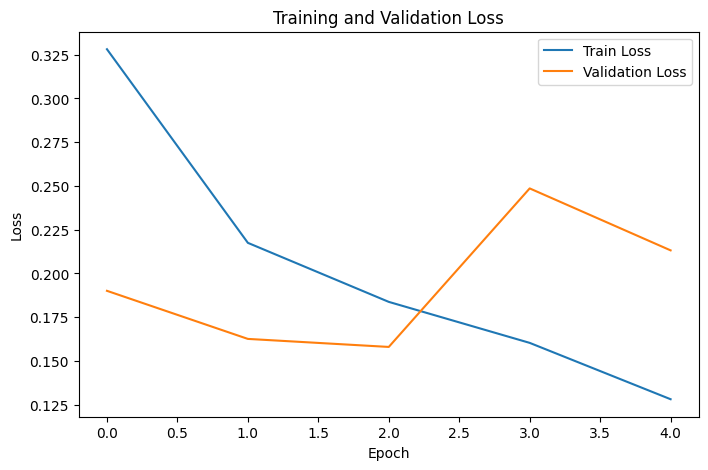

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Training and Validation Loss Analysis

The training loss decreased consistently across all epochs, indicating that the model successfully learned meaningful patterns from the training dataset.

The validation loss initially decreased and achieved its best performance around Epoch 2–3, showing strong generalization capability on unseen validation data.

However, after later epochs, a slight increase in validation loss was observed while training loss continued to decrease. This behavior suggests mild overfitting, where the model begins to memorize training data more than generalizing to new samples.

Despite this, the overall validation loss remained relatively low, indicating stable and effective learning performance.

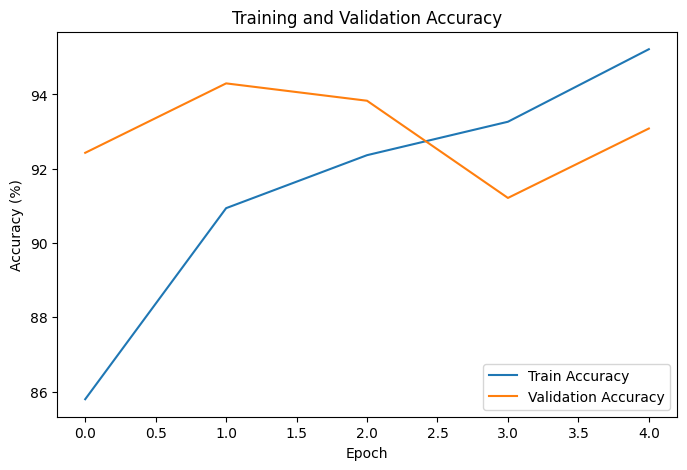

In [31]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(valid_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

### Training and Validation Accuracy Analysis

Training accuracy improved steadily throughout the training process, increasing from approximately 85% to over 95%, demonstrating successful model optimization.

Validation accuracy remained consistently high between 92% and 94%, indicating that the model generalized well to unseen chest X-ray images.

The highest validation accuracy was achieved around Epoch 2, reaching approximately 94.3%. After this point, validation accuracy fluctuated slightly while training accuracy continued to improve, which further supports the presence of mild overfitting.

Overall, the model achieved strong classification performance and demonstrated reliable learning behavior on the medical imaging dataset.

The training loss decreased steadily across epochs, indicating successful learning behavior of the model.

Validation accuracy reached its peak around Epoch 2, achieving approximately 94% accuracy. 

After later epochs, a slight increase in validation loss was observed, suggesting mild overfitting while maintaining strong classification performance overall.